---
title: "Python 基础入门(4)"
description: "本内容面向的读者是没有编程经验的纯编程小白，可以帮助你学习 Python 基础"
date: 2026-08-31

categories:
  - Python
  - Code
---

## 常用数据结构

上一篇我们学了函数、lambda、列表推导式等语法糖。这篇是整个 Python 教程中最重要的一篇——我们要系统学习 Python 中刷算法题最常用的数据结构。

算法题的本质就是对数据结构进行操作，如果你不熟悉这些数据结构的基本用法，看算法代码就会一头雾水。好消息是，Python 的数据结构用起来非常简洁直观，你不需要记住所有 API，只需要掌握最常用的那几个操作就够了。用多了自然就记住了，忘了随时可以回来查。

### 列表 list

列表是 Python 中最基础、最常用的数据结构，你可以把它理解为"可变长度的数组"。几乎所有算法题都离不开它。

#### 创建与初始化

```{pyodide}
#| caption: "列表的创建与初始化"
# 方式一：直接用方括号创建
nums = [1, 2, 3, 4, 5]
# 输出：[1, 2, 3, 4, 5]
print(nums)

# 方式二：创建空列表
empty = []
# 输出：[]
print(empty)

# 方式三：用 * 快速创建指定长度的列表
# 创建长度为 5 的列表，初始值都是 0
zeros = [0] * 5
# 输出：[0, 0, 0, 0, 0]
print(zeros)

# 方式四：列表推导式创建二维列表（最重要！）
# 创建 3 行 4 列的二维列表，初始值为 0
rows, cols = 3, 4
grid = [[0] * cols for _ in range(rows)]
# 输出：[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
print(grid)

# 修改某个元素验证独立性
grid[1][2] = 99
# 输出：[[0, 0, 0, 0], [0, 0, 99, 0], [0, 0, 0, 0]]
# 只有 grid[1] 变了，其他行不受影响
print(grid)
```

#### 常用操作

```{pyodide}
#| caption: "列表的增删操作"
nums = [1, 2, 3]

# append：在末尾追加元素（最常用）
nums.append(4)
nums.append(5)
# 输出：[1, 2, 3, 4, 5]
print(nums)

# pop：删除并返回末尾元素
last = nums.pop()
# 输出：5
print(last)
# 输出：[1, 2, 3, 4]
print(nums)

# pop(i)：删除并返回索引 i 处的元素
second = nums.pop(1)
# 输出：2
print(second)
# 输出：[1, 3, 4]
print(nums)

# insert(i, x)：在索引 i 处插入元素 x
nums.insert(1, 99)
# 输出：[1, 99, 3, 4]
print(nums)

# del：删除指定索引的元素
del nums[1]
# 输出：[1, 3, 4]
print(nums)

# len：获取列表长度
# 输出：3
print(len(nums))
```

`append` 和 `pop` 是刷题时用得最多的两个操作，它们操作的都是列表末尾，时间复杂度 O(1)。而 `pop(i)`、`insert(i, x)`、`del` 操作的是中间位置，需要移动元素，时间复杂度 O(n)。

#### 切片操作

切片是 Python 的一大特色，能非常灵活地截取列表的一部分：

```{pyodide}
#| caption: "切片操作"
nums = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# 基本语法：nums[start:end]，包含 start，不包含 end
# 输出：[2, 3, 4]
print(nums[2:5])

# 省略 start 表示从头开始
# 输出：[0, 1, 2]
print(nums[:3])

# 省略 end 表示到末尾
# 输出：[7, 8, 9]
print(nums[7:])

# 带步长：nums[start:end:step]
# 每隔一个取一个
# 输出：[0, 2, 4, 6, 8]
print(nums[::2])

# 负索引：-1 表示最后一个元素
# 输出：9
print(nums[-1])
# 输出：[7, 8, 9]
print(nums[-3:])

# 反转列表：步长为 -1
# 输出：[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
print(nums[::-1])
```

切片用得最多的场景：`nums[:i] + nums[i+1:]` 跳过索引 `i` 的元素，`nums[::-1]` 反转列表。这些在刷题时非常常见。

#### 遍历列表

```{pyodide}
#| caption: "遍历列表"
fruits = ["apple", "banana", "cherry"]

# 方式一：直接遍历元素
for fruit in fruits:
    print(fruit, end=" ")
# 输出：apple banana cherry
print()

# 方式二：用 enumerate 同时获取索引和元素（推荐！）
for i, fruit in enumerate(fruits):
    print(f"索引 {i}: {fruit}")
# 输出：
# 索引 0: apple
# 索引 1: banana
# 索引 2: cherry

# 方式三：用 range(len()) 遍历索引
for i in range(len(fruits)):
    print(f"{i}: {fruits[i]}", end="  ")
# 输出：0: apple  1: banana  2: cherry
print()
```

推荐用 `enumerate`，因为大部分时候你既需要索引又需要元素值。直接写 `for i, val in enumerate(nums)` 就行，比 `for i in range(len(nums))` 然后再 `nums[i]` 取值要简洁得多。

### 元组 tuple

元组和列表长得很像，但有一个关键区别：**元组创建后不能修改**。

```{pyodide}
#| caption: "元组基础"
# 创建元组，用小括号
t = (1, 2, 3)
# 输出：(1, 2, 3)
print(t)

# 访问元素（和列表一样用下标）
# 输出：1
print(t[0])

# 长度
# 输出：3
print(len(t))

# 元组不能修改！下面的写法会报错：
# t[0] = 99  # TypeError!

# 元组拆包：把元组的值分别赋给多个变量
a, b, c = (10, 20, 30)
# 输出：10 20 30
print(a, b, c)

# 交换两个变量的值（本质就是元组拆包）
x, y = 1, 2
x, y = y, x
# 输出：2 1
print(x, y)
```

你可能会问：既然元组不能修改，那为什么还要用它？元组在刷题中主要有三个用途：

1. **多返回值**：函数返回多个值时，实际上返回的是元组，用拆包接收
2. **字典的键**：列表不能当字典的键（因为可变），但元组可以
3. **排序的 key**：用元组做排序的 key 可以实现多级排序，比如 `key=lambda x: (x[1], x[0])`

```{pyodide}
#| caption: "元组的实际用途"
# 用途一：多返回值（上一篇讲过）
def min_max(nums):
    return min(nums), max(nums)

lo, hi = min_max([3, 1, 4, 1, 5, 9])
# 输出：最小值 = 1, 最大值 = 9
print(f"最小值 = {lo}, 最大值 = {hi}")

# 用途二：元组可以当字典的键
# 比如用 (行, 列) 坐标作为 key
visited = {}
visited[(0, 0)] = True
visited[(1, 2)] = True
# 输出：True
print((0, 0) in visited)

# 用途三：多级排序
# 先按成绩降序，成绩相同按姓名升序
students = [("Alice", 88), ("Bob", 95), ("Charlie", 88), ("Diana", 95)]
students.sort(key=lambda x: (-x[1], x[0]))
# 输出：[('Bob', 95), ('Diana', 95), ('Alice', 88), ('Charlie', 88)]
print(students)
```
多级排序这个技巧非常实用：元组在比较时会先比第一个元素，相等再比第二个，以此类推。想要降序就取负号。

### 字符串 str

Python 的字符串也是不可变的——你不能修改字符串中的某个字符，想修改就只能创建新字符串。

#### 基本操作

```{pyodide}
#| caption: "字符串基本操作"
s = "Hello, Python!"

# 长度
# 输出：14
print(len(s))

# 下标访问
# 输出：H
print(s[0])
# 输出：!
print(s[-1])

# 切片（和列表切片完全一样）
# 输出：Hello
print(s[0:5])
# 输出：Python!
print(s[7:])

# 字符串反转
# 输出：!nohtyP ,olleH
print(s[::-1])

# 字符串拼接用 +
greeting = "Hello" + " " + "World"
# 输出：Hello World
print(greeting)

# 字符串不可变！下面会报错：
# s[0] = 'h'  # TypeError!

# 想修改？转成列表再转回来
chars = list(s)
chars[0] = 'h'
s_new = "".join(chars)
# 输出：hello, Python!
print(s_new)

# in 判断：检查子串是否存在
# 输出：True
print("Python" in s)
# 输出：False
print("World" in s)
```
字符串不可变这个特点很重要：每次用 `+` 拼接字符串，实际上都会创建一个新的字符串对象。如果在循环里频繁拼接，效率会很低。后面会讲更高效的做法。

#### 常用方法

```{pyodide}
#| caption: "常用方法"
s = "  Hello, World!  "

# strip：去除两端空白字符
# 输出：'Hello, World!'
print(s.strip())

# split：按分隔符切分，返回列表
csv = "apple,banana,cherry"
# 输出：['apple', 'banana', 'cherry']
print(csv.split(","))

# 不传参数默认按空白字符切分（空格、换行等）
text = "hello  world   python"
# 输出：['hello', 'world', 'python']
print(text.split())

# join：把列表用分隔符连接成字符串
words = ["I", "love", "Python"]
# 输出：I love Python
print(" ".join(words))

# find：查找子串位置，找不到返回 -1
s2 = "hello world"
# 输出：6
print(s2.find("world"))
# 输出：-1
print(s2.find("python"))

# replace：替换子串
# 输出：hello python
print(s2.replace("world", "python"))

# startswith / endswith
# 输出：True
print(s2.startswith("hello"))
# 输出：True
print(s2.endswith("world"))

# lower / upper：大小写转换
# 输出：hello world
print("Hello World".lower())
# 输出：HELLO WORLD
print("Hello World".upper())
```
刷题时最常用的字符串方法：`split` 用于解析输入，`join` 用于拼接输出，`find` 用于查找子串，`strip` 用于去除多余空白。

#### 字符与 ASCII

算法题中经常需要操作单个字符和 ASCII 码，Python 用 `ord()` 和 `chr()` 来转换：

```{pyodide}
#| caption: "字符与 ASCII"
# ord：字符 -> ASCII 码
# 输出：97
print(ord('a'))
# 输出：65
print(ord('A'))
# 输出：48
print(ord('0'))

# chr：ASCII 码 -> 字符
# 输出：a
print(chr(97))
# 输出：Z
print(chr(90))

# 常见用法：判断字符类型
ch = 'c'
# 判断是否是小写字母
# 输出：True
print('a' <= ch <= 'z')

# 计算字母在字母表中的位置（0-based）
# 输出：2（c 是第 3 个字母，索引从 0 开始）
print(ord(ch) - ord('a'))

# 经典用法：用数组统计字母频率
text = "abracadabra"
freq = [0] * 26
for ch in text:
    freq[ord(ch) - ord('a')] += 1

# 输出每个出现过的字母及其频率
for i in range(26):
    if freq[i] > 0:
        print(f"{chr(i + ord('a'))}: {freq[i]}", end="  ")
# 输出：a: 5  b: 2  c: 1  d: 1  r: 2
print()
```
`ord(ch) - ord('a')`这个技巧把小写字母映射到 0~25，非常适合用数组代替哈希表来统计字母频率。刷题时很常用。

### 字典 dict

字典是 Python 中的哈希表实现，存储键值对，增删查改都很快（平均 O(1)）。这里只讲用法



#### 常用操作

```{pyodide}
#| caption: "常用操作"
# 创建字典
d = {"apple": 3, "banana": 5, "cherry": 2}

# 取值
# 输出：3
print(d["apple"])

# 赋值（key 存在就修改，不存在就新增）
d["apple"] = 10
d["grape"] = 7
# 输出：{'apple': 10, 'banana': 5, 'cherry': 2, 'grape': 7}
print(d)

# in 判断 key 是否存在
# 输出：True
print("banana" in d)
# 输出：False
print("mango" in d)

# del 删除键值对
del d["cherry"]
# 输出：{'apple': 10, 'banana': 5, 'grape': 7}
print(d)

# len 获取键值对数量
# 输出：3
print(len(d))

# 遍历方式
# 遍历 key
for key in d:
    print(key, end=" ")
# 输出：apple banana grape
print()

# 遍历 key-value 对（最常用）
for key, value in d.items():
    print(f"{key}: {value}", end="  ")
# 输出：apple: 10  banana: 5  grape: 7
print()

# 只遍历 values
# 输出：22
print(sum(d.values()))
```

#### get 方法与默认值

直接用 `d[key]` 取值时，如果 `key` 不存在会报 `KeyError`。用 get 方法可以避免这个问题：

```{pyodide}
#| caption: "get 方法与默认值"
d = {"apple": 3, "banana": 5}

# get(key, default)：key 不存在时返回默认值，不会报错
# 输出：3
print(d.get("apple", 0))
# 输出：0（key 不存在，返回默认值 0）
print(d.get("mango", 0))

# 频率统计的经典写法
text = "hello world"
freq = {}
for ch in text:
    # 如果 ch 不在字典中，get 返回 0，加 1 后就是 1
    freq[ch] = freq.get(ch, 0) + 1

# 输出：{'h': 1, 'e': 1, 'l': 3, 'o': 2, ' ': 1, 'w': 1, 'r': 1, 'd': 1}
print(freq)

# 找出出现次数最多的字符
max_char = max(freq, key=lambda ch: freq[ch])
# 输出：出现最多的字符：l，出现了 3 次
print(f"出现最多的字符：{max_char}，出现了 {freq[max_char]} 次")
```

`freq[ch] = freq.get(ch, 0) + 1` 这是 Python 中频率统计的经典写法，一行搞定，不需要提前判断 key 是否存在。几乎每道跟"计数"相关的算法题都会用到这个套路。

### 集合 set

集合是一个不包含重复元素的无序容器，底层也是用哈希表实现的。它最大的特点是 `in` 判断非常快（O(1)），比列表的 `in`（O(n)）快得多。

```{pyodide}
#| caption: "常用操作"
# 创建集合
s = {1, 2, 3, 4, 5}
# 输出：{1, 2, 3, 4, 5}
print(s)

# 从列表创建集合（自动去重）
nums = [1, 2, 2, 3, 3, 3]
s2 = set(nums)
# 输出：{1, 2, 3}
print(s2)

# add：添加元素
s.add(6)
s.add(3)  # 已存在，不会重复添加
# 输出：{1, 2, 3, 4, 5, 6}
print(s)

# discard：删除元素（不存在也不会报错）
s.discard(3)
s.discard(99)  # 不存在，不报错
# 输出：{1, 2, 4, 5, 6}
print(s)

# in 判断（O(1)，非常快）
# 输出：True
print(4 in s)
# 输出：False
print(99 in s)

# len：集合大小
# 输出：5
print(len(s))

# 集合运算
a = {1, 2, 3, 4}
b = {3, 4, 5, 6}

# 交集 &
# 输出：{3, 4}
print(a & b)

# 并集 |
# 输出：{1, 2, 3, 4, 5, 6}
print(a | b)

# 差集 -（在 a 中但不在 b 中）
# 输出：{1, 2}
print(a - b)
```

什么时候用集合而不是列表？当你需要频繁判断"某个元素是否存在"的时候，一定要用集合。比如 BFS 中记录已访问的节点、两数之和中查找补数等场景，用集合比用列表效率高得多。

### 栈（list 模拟）

栈是"后进先出"（LIFO）的数据结构。Python 没有专门的栈类型，直接用列表就能模拟——`append` 入栈，`pop` 出栈，`[-1]` 看栈顶。

```{pyodide}
#| caption: "栈（list 模拟）"
stack = []

# 入栈
stack.append(1)
stack.append(2)
stack.append(3)
# 输出：[1, 2, 3]（3 在栈顶）
print(stack)

# 查看栈顶元素（不删除）
# 输出：3
print(stack[-1])

# 出栈（删除并返回栈顶元素）
top = stack.pop()
# 输出：3
print(top)
# 输出：[1, 2]
print(stack)

# 判空
# 输出：False
print(len(stack) == 0)

# 全部出栈
stack.pop()
stack.pop()
# 输出：True
print(len(stack) == 0)
```

栈的操作总结：

- 入栈：`stack.append(x)`
- 栈顶：`stack[-1]`
- 出栈：`stack.pop()`
- 判空：`len(stack) == 0`

这四个操作在括号匹配、单调栈等算法题中用得非常多。来看一个经典例子——括号匹配：

```{pyodide}
#| caption: "括号匹配"
def is_valid(s):
    stack = []
    # 用字典存储括号的对应关系
    pairs = {')': '(', ']': '[', '}': '{'}

    for ch in s:
        if ch in '([{':
            # 左括号入栈
            stack.append(ch)
        else:
            # 右括号：检查是否与栈顶匹配
            if not stack or stack[-1] != pairs[ch]:
                return False
            stack.pop()

    # 最后栈必须为空
    return len(stack) == 0

# 输出：True
print(is_valid("()[]{}"))
# 输出：True
print(is_valid("{[()]}"))
# 输出：False
print(is_valid("(]"))
# 输出：False
print(is_valid("([)]"))
# 输出：False
print(is_valid("("))
```

### 队列（deque）

队列是"先进先出"（FIFO）的数据结构，在 BFS（广度优先搜索）中必用。Python 用 `collections.deque`（双端队列）来实现高效的队列操作。

你可能会想：用列表不行吗？用列表的 `pop(0)` 也能实现出队，但 `pop(0)` 需要把后面所有元素往前移一位，时间复杂度 O(n)。而 `deque` 的 `popleft` 是 O(1) 的，效率高得多。

```{pyodide}
#| caption: "deque"
from collections import deque

queue = deque()

# 入队：从右端添加
queue.append(1)
queue.append(2)
queue.append(3)
# 输出：deque([1, 2, 3])
print(queue)

# 查看队头元素
# 输出：1
print(queue[0])

# 出队：从左端弹出
front = queue.popleft()
# 输出：1
print(front)
# 输出：deque([2, 3])
print(queue)

# 队列长度
# 输出：2
print(len(queue))

# 判空
# 输出：False
print(len(queue) == 0)
```

队列的操作总结：

- 入队：queue.append(x)
- 队头：queue[0]
- 出队：queue.popleft()
- 判空：len(queue) == 0

deque 其实是双端队列，两端都能高效地添加和删除。除了 `append` 和 `popleft`，还有 `appendleft`（从左端添加）和 `pop`（从右端弹出），但刷题时主要用前面两个就够了。

来看一个 BFS 的例子：

```{pyodide}
#| caption: "BFS"
from collections import deque

# 用邻接表表示一个图
# 0 -> 1, 2
# 1 -> 3
# 2 -> 3, 4
graph = {
    0: [1, 2],
    1: [3],
    2: [3, 4],
    3: [],
    4: [],
}

# BFS 从节点 0 开始
visited = set()
queue = deque()
queue.append(0)
visited.add(0)

result = []
while queue:
    node = queue.popleft()
    result.append(node)

    for neighbor in graph[node]:
        if neighbor not in visited:
            visited.add(neighbor)
            queue.append(neighbor)

# 输出：BFS 遍历顺序: [0, 1, 2, 3, 4]
print("BFS 遍历顺序:", result)
```

注意这里用 `set` 来记录已访问节点，用 `deque` 当队列，这是 BFS 的标准模板。

### 小结

把这篇的数据结构和核心操作汇总一下：

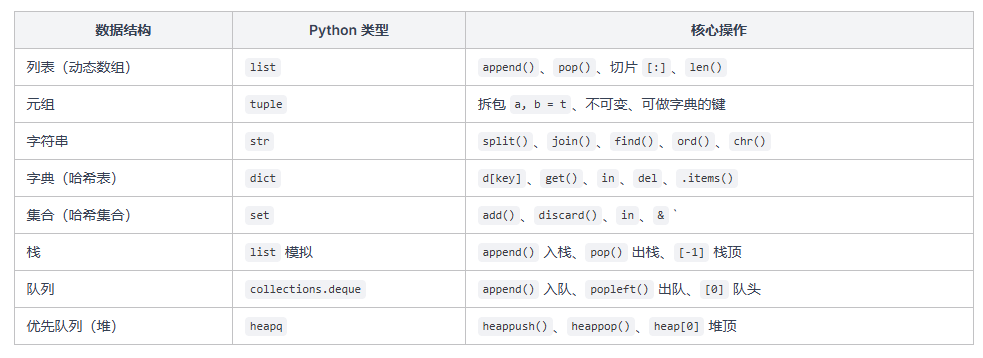
